In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

In [64]:
transactions = [
    ["pen", "bread", "butter"],
    ["bread", "butter", "egg", "milk"],
    ["vegetables", "egg", "milk"],
    ["bread", "butter"],
    ["bread", "butter", "soy sauce", "egg", "milk"]
]

df = pd.DataFrame({'Product purchased': transactions})

total_transactions = len(transactions)
print(f"Total transactions: {total_transactions}")

df.head()

Total transactions: 5


,Product purchased
0,"[pen, bread, butter]"
1,"[bread, butter, egg, milk]"
2,"[vegetables, egg, milk]"
3,"[bread, butter]"
4,"[bread, butter, soy sauce, egg, milk]"


In [65]:
# Membuat function support, confidence, dan lift
def support(product):
    count = 0
    for transaction in transactions:
        # Ubah ke set
        product_set = set(product)
        transaction_set = set(transaction)
        
        # Periksa apakah product ada dalam transaksi
        if product_set.issubset(transaction_set):
            count += 1
            
    return count / total_transactions

def confidence(A, B):
    return support(A + B) / support(A)

def lift(A, B):
    return confidence(A, B) / support(B)

In [66]:
# List produk questin

list_products = [
    (['bread'], ['butter']),
    (['bread'], ['egg']),
    (['egg'], ['milk']),
    (['bread', 'butter'], ['milk'])
]

In [67]:
# Menghitung Metriks

results = []
for A, B in list_products:
    sup = support(A + B)
    conf = confidence(A, B)
    lf = lift(A, B)
    results.append(
        {'list_products': f"{A} => {B}",
         'support': sup,
         'confidence': conf,
         'lift': lf}
    )
    
results_df = pd.DataFrame(results)
print(results_df)

                     list_products  support  confidence      lift
0          ['bread'] => ['butter']      0.8         1.0  1.250000
1             ['bread'] => ['egg']      0.4         0.5  0.833333
2              ['egg'] => ['milk']      0.6         1.0  1.666667
3  ['bread', 'butter'] => ['milk']      0.4         0.5  0.833333


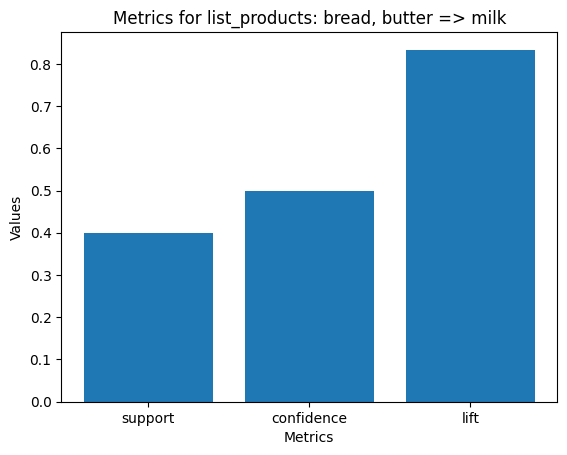

In [68]:
target_list_products = next(r for r in results if r['list_products'] == "['bread', 'butter'] => ['milk']")

metrics = ['support', 'confidence', 'lift']
values = [target_list_products[m] for m in metrics]

plt.figure()
plt.bar(metrics, values)
plt.title("Metrics for list_products: bread, butter => milk")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()
